In [ ]:

# STEP 0: Install Dependencies
# ============================
!pip install rasterio tensorflow xarray pandas openpyxl matplotlib scikit-learn pytz pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 59.0 MB/s eta 0:00:00


In [ ]:
# STEP 1: Import Libraries
# ============================
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import pytz
from datetime import datetime, timedelta
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (ConvLSTM2D, BatchNormalization, Reshape, Attention, Flatten,
                                     Dense, Dropout)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pvlib.location import Location


In [ ]:
# STEP 2: Mount to Drive
# ============================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# STEP 3: Load & Process INSAT Data
# ============================
input_directory = "/content/drive/MyDrive/solar_project/2019_Data/"
output_directory = "/content/drive/MyDrive/solar_project/p1"
os.makedirs(output_directory, exist_ok=True)

def load_insat_data(hdf5_file, dataset_name):
    with h5py.File(hdf5_file, 'r') as f:
        if dataset_name not in f:
            return None
        return f[dataset_name][:]

def process_hdf5(file_path, dataset_name):
    data = load_insat_data(file_path, dataset_name)
    return data if data is not None else None

h5_files = [f for f in os.listdir(input_directory) if f.endswith(".h5")]
dataset_name = "IMG_VIS"

for filename in h5_files:
    file_path = os.path.join(input_directory, filename)
    processed_data = process_hdf5(file_path, dataset_name)
    if processed_data is not None:
        output_file = os.path.join(output_directory, filename.replace(".h5", ".npy"))
        np.save(output_file, processed_data)
        print(f"Saved processed data to {output_file}")
    else:
        print(f"Failed to process {filename}")


Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_0630_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_1030_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_0900_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_0730_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_0330_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_12SEP2019_1030_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_0300_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_12SEP2019_0630_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_project/p1/3DIMG_03SEP2019_0130_L1C_ASIA_MER_B1.npy
Saved processed data to /content/drive/MyDrive/solar_pr

In [ ]:
# STEP 4: Clip Satellite Images
# ============================
Clipped_directory = "/content/drive/MyDrive/solar_project/p1_clipped"
os.makedirs(Clipped_directory, exist_ok=True)

def extract_insat_region(insat_data, lat, lon, bbox_size=(150, 150)):
    height, width = insat_data.shape[1:]
    row = int(lat * height / 360)
    col = int(lon * width / 360)
    row_start = max(0, row - bbox_size[0] // 2)
    row_end = min(height, row + bbox_size[0] // 2)
    col_start = max(0, col - bbox_size[1] // 2)
    col_end = min(width, col + bbox_size[1] // 2)
    window = (slice(row_start, row_end), slice(col_start, col_end))
    region_data = insat_data[:, window[0], window[1]]
    if region_data.size == 0:
        raise ValueError("Extracted region is empty. Check latitude and longitude values or bbox_size.")
    return (region_data - np.min(region_data)) / (np.max(region_data) - np.min(region_data))

lat, lon = 13.627, 79.397
npy_files = [f for f in os.listdir(output_directory) if f.endswith(".npy")]

for npy_file in npy_files:
    npy_path = os.path.join(output_directory, npy_file)
    insat_data = np.load(npy_path)
    clipped_insat_images = extract_insat_region(insat_data, lat, lon)
    num_frames, height, width = clipped_insat_images.shape
    clipped_insat_images = clipped_insat_images.reshape((num_frames, height, width, 1))
    output_file = os.path.join(Clipped_directory, npy_file)
    np.save(output_file, clipped_insat_images)
    print(f"Saved clipped images to {output_file}")


Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_0630_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_12SEP2019_0630_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_0900_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_0330_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_0300_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_0730_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_1030_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_03SEP2019_0130_L1C_ASIA_MER_B1.npy
Saved clipped images to /content/drive/MyDrive/solar_project/p1_clipped/3DIMG_12SEP2019_1030_L1C

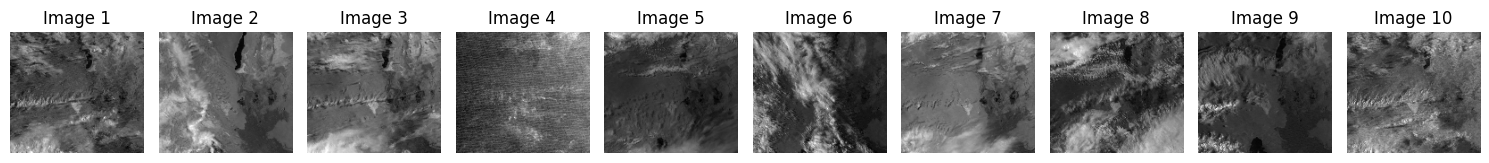

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 113s 16s/step - loss: 0.0437 - val_loss: 0.0396
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 130s 14s/step - loss: 0.0388 - val_loss: 0.0315
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 104s 15s/step - loss: 0.0276 - val_loss: 0.0236
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 137s 14s/step - loss: 0.0219 - val_loss: 0.0213
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 139s 14s/step - loss: 0.0192 - val_loss: 0.0181
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 115s 17s/step - loss: 0.0158 - val_loss: 0.0144
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 106s 15s/step - loss: 0.0129 - val_loss: 0.0135
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 137s 15s/step - loss: 0.0123 - val_loss: 0.0121
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 103s 15s/step - loss: 0.0118 - val_loss: 0.0121
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 101s 15s/step - loss: 0.0109 - val_loss: 0.0113
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 112s 17s/step - loss: 0.0106 - val_loss: 0.0097
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 134s 15s/step - loss: 0.0089 - val_lo

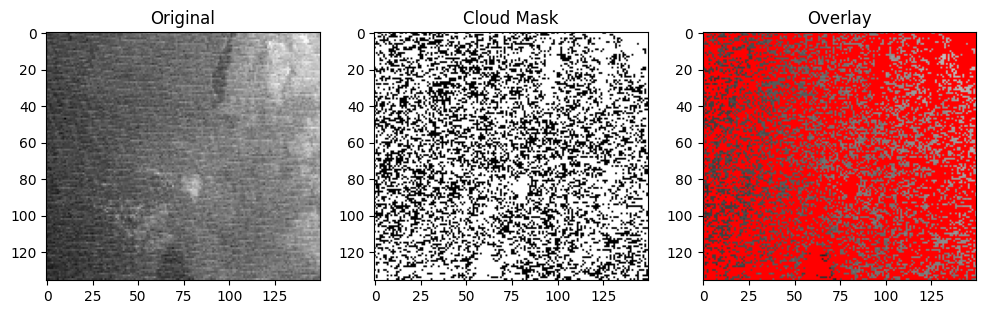

Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0130_L1C_ASIA_MER_B1.npy


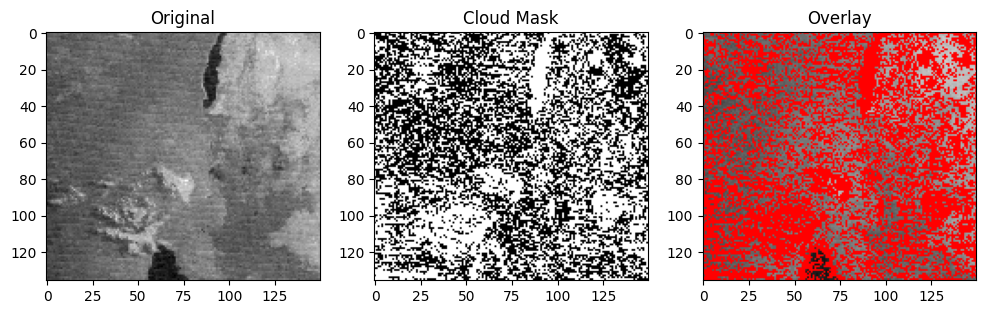

Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0200_L1C_ASIA_MER_B1.npy


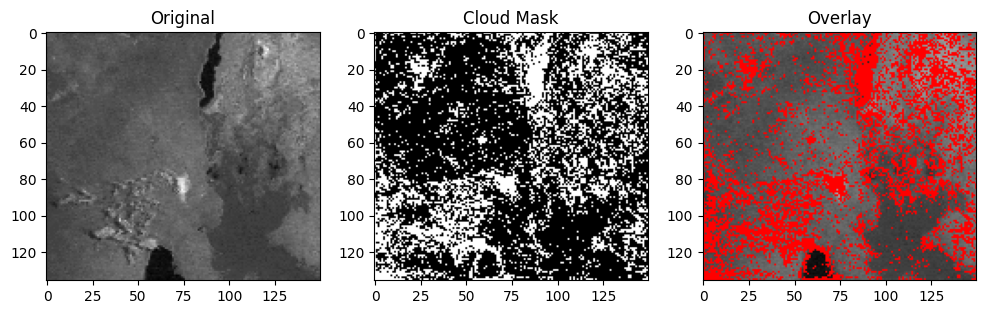

Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0230_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0300_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0330_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0400_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0430_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0500_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0530_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0600_L1C_ASIA_MER_B1.npy
Saved mask: /content/drive/MyDrive/solar_project/cloud_masks/cloudmask_3DIMG_01SEP2019_0630_L1C_ASIA_MER

In [ ]:
# STEP 5: Prepare Image Stack
# ============================
input_directory = Clipped_directory
npy_files = [f for f in os.listdir(input_directory) if f.endswith(".npy")]
image_stack = []

for npy_file in npy_files:
    npy_path = os.path.join(input_directory, npy_file)
    images = np.load(npy_path)
    if images.ndim == 2:
        images = np.expand_dims(images, axis=0)
    for img in images:
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=-1)
        image_stack.append(img)

num_images_to_plot = min(10, len(image_stack))
plt.figure(figsize=(15, 5))
for i in range(num_images_to_plot):
    plt.subplot(1, num_images_to_plot, i + 1)
    plt.imshow(image_stack[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f'Image {i+1}')
plt.tight_layout()
plt.show()

# ============================
# STEP 6: Generate Cloud Masks
# ============================
data_dir = Clipped_directory
mask_output_dir = "/content/drive/MyDrive/solar_project/cloud_masks"
os.makedirs(mask_output_dir, exist_ok=True)
image_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

X = np.array([np.load(os.path.join(data_dir, f)) for f in image_files])
X = X.astype(np.float32)
X = (X - X.min()) / (X.max() - X.min() + 1e-6)
X = X.squeeze()
X = X[..., np.newaxis]

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

latent_dim = 64

def build_autoencoder(input_shape):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = Flatten()(x)
    latent_space = Dense(latent_dim, activation='relu')(encoded)
    x = Dense(input_shape[0]*input_shape[1]*16, activation='relu')(latent_space)
    x = Reshape((input_shape[0], input_shape[1], 16))(x)
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
    decoded = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')(x)
    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

autoencoder = build_autoencoder(input_shape=X.shape[1:])
autoencoder.fit(X_train, X_train, epochs=20, batch_size=50, validation_split=0.2)

def get_cloud_mask(original, reconstructed, threshold=0.08):
    error_map = np.abs(original - reconstructed)
    norm_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-6)
    mask = (norm_error > threshold).astype(np.uint8)
    return mask.squeeze(), norm_error.squeeze()

for i, img in enumerate(X):
    recon = autoencoder.predict(img[np.newaxis], verbose=0)[0]
    mask, err_map = get_cloud_mask(img, recon)
    mask_path = os.path.join(mask_output_dir, f"cloudmask_{image_files[i].replace('.npy','')}.npy")
    np.save(mask_path, mask)
    if i < 3:
        plt.figure(figsize=(12, 4))
        plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap='gray'); plt.title("Original")
        plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Cloud Mask")
        plt.subplot(1,3,3)
        overlay = np.stack([img.squeeze()]*3, axis=-1); overlay[mask==1] = [1,0,0]
        plt.imshow(overlay); plt.title("Overlay")
        plt.show()
    print(f"Saved mask: {mask_path}")


In [ ]:
# STEP 7: Match GHI Labels
# ============================
ghi_xls_path = "/content/drive/MyDrive/solar_project/tirupati_ground_data.xlsx"
ghi_df = pd.read_excel(ghi_xls_path)
ghi_df['Date'] = pd.to_datetime(ghi_df['Date'])
ghi_df['Date_utc'] = ghi_df['Date'] - timedelta(hours=5, minutes=30)

mask_dir = mask_output_dir
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(".npy")])
file_timestamps = []
for fname in mask_files:
    parts = fname.split('_')
    date_part, time_part = parts[2], parts[3]
    ts = datetime.strptime(date_part + time_part, "%d%b%Y%H%M")
    file_timestamps.append(ts)

ghi_labels = []
for ts in file_timestamps:
    match = ghi_df[ghi_df['Date_utc']==ts]
    ghi_labels.append(match.iloc[0]['Ground_data'] if not match.empty else np.nan)

ghi_labels = np.array(ghi_labels)
np.save("/content/drive/MyDrive/solar_project/ghi_labels.npy", ghi_labels)
print("GHI labels saved.")

# ============================

GHI labels saved.


In [ ]:
# ==== STEP 8: FEATURE ENGINEERING & SEQUENCE CREATION ====
from sklearn.preprocessing import MinMaxScaler

# Location & time
altitude = 194
lat, lon = 13.627, 79.397
AOI = 'tirupati'
starttime = '2019-09-01 00:00:00'
endtime = '2019-09-30 23:59:00'

# Clear-sky estimation
date_range = pd.date_range(start=starttime, end=endtime, freq='1min')
location = Location(lat, lon, altitude=altitude, name=AOI)
clearsky = location.get_clearsky(date_range, model='simplified_solis')
clearsky.index = clearsky.index.tz_localize('UTC')
clear_ghi = clearsky['ghi'].values

# Load cloud masks
mask_dir = '/content/drive/MyDrive/solar_project/cloud_masks'
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(".npy")])
file_timestamps, all_means, all_masks = [], [], []

for fname in mask_files:
    parts = fname.split('_')
    date_part, time_part = parts[2], parts[3].replace(".npy","")
    ts = datetime.strptime(date_part + time_part, "%d%b%Y%H%M")
    ts = pd.to_datetime(ts).tz_localize('UTC')
    mask = np.load(os.path.join(mask_dir, fname))

    file_timestamps.append(ts)
    all_means.append(mask.mean())
    all_masks.append(mask)

cloud_mask_times = pd.to_datetime(file_timestamps)
cloud_mask_values = np.array(all_means)
cloud_masks = np.array(all_masks)

# Compute cloud index (proper normalization)
nmin, nmax = np.percentile(cloud_mask_values, 5), np.percentile(cloud_mask_values, 95)
cloud_index = 1 - (cloud_mask_values - nmin) / (nmax - nmin)
cloud_index = np.clip(cloud_index, 0, 1)
cloud_index = pd.Series(cloud_index, index=cloud_mask_times).rolling('15min').mean().bfill().values

# Actual GHI = clear_sky * cloud index
actual_ghi = []
valid_indices = []

for i, ts in enumerate(cloud_mask_times):
    ts_rounded = ts.floor('min')
    if ts_rounded in clearsky.index:
        ghi_val = clearsky.loc[ts_rounded]['ghi']
        actual_ghi.append(ghi_val * cloud_index[i])
        valid_indices.append(i)
    else:
        actual_ghi.append(np.nan)

actual_ghi = np.array(actual_ghi)
valid_mask = ~np.isnan(actual_ghi)
actual_ghi = actual_ghi[valid_mask]
file_timestamps = np.array(file_timestamps)[valid_mask]
cloud_masks = cloud_masks[valid_mask]
cloud_index = cloud_index[valid_mask]
clear_ghi = clearsky.loc[file_timestamps]['ghi'].values

# ==== NORMALIZATION ====
scaler = MinMaxScaler()
all_values = np.concatenate([actual_ghi.reshape(-1,1), clear_ghi.reshape(-1,1)], axis=0)
scaler.fit(all_values)

ghi_norm = scaler.transform(actual_ghi.reshape(-1,1)).flatten()
clear_ghi_norm = scaler.transform(clear_ghi.reshape(-1,1)).flatten()

# ==== FEATURES (Include cloud_index as feature) ====
hour = np.array([np.sin(2*np.pi*ts.hour/24) for ts in file_timestamps])
minute = np.array([np.sin(2*np.pi*ts.minute/60) for ts in file_timestamps])
cloud_feat = cloud_index  # Include cloud index as additional feature
features = np.stack([ghi_norm, clear_ghi_norm, cloud_feat, hour, minute], axis=1)

# ==== SEQUENCE CREATION ====
seq_len, pred_len = 6, 4
X, y, time_y, masks_seq = [], [], [], []

for i in range(len(features)-seq_len-pred_len+1):
    input_seq = features[i:i+seq_len]
    output_seq = ghi_norm[i+seq_len:i+seq_len+pred_len]
    if np.isnan(output_seq).any(): continue
    X.append(input_seq)
    y.append(output_seq)
    time_y.append(file_timestamps[i+seq_len:i+seq_len+pred_len])
    masks_seq.append(cloud_masks[i+seq_len-1])

X = np.array(X, dtype='float32').reshape(-1, seq_len, 1, 1, features.shape[1])
y = np.array(y, dtype='float32')
time_y = np.array(time_y)
masks_seq = np.array(masks_seq, dtype='float32')

# ==== TRAIN / VAL SPLIT ====
X_train, X_val, y_train, y_val, time_train, time_val, masks_train, masks_val = train_test_split(
    X, y, time_y, masks_seq, test_size=0.2, random_state=42
)


In [ ]:
# ==== STEP 9: IMPROVED CONVLSTM + MULTIHEAD ATTENTION MODEL ====
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Reshape, Flatten, Dense, Dropout

seq_input = Input(shape=(seq_len, 1, 1, features.shape[1]))

x = ConvLSTM2D(64, (1,1), activation='tanh', return_sequences=True)(seq_input)
x = LayerNormalization()(x)
x = ConvLSTM2D(64, (1,1), activation='tanh', return_sequences=True)(x)
x = LayerNormalization()(x)

x = Reshape((seq_len, 64))(x)
attn_out = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)

x = Flatten()(attn_out)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(pred_len)(x)

model = tf.keras.Model(seq_input, output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='huber', metrics=['mae'])
model.summary()

# ==== CALLBACKS ====
early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(patience=7, factor=0.3, verbose=1)
checkpoint = callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss")

# ==== TRAIN ====
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,   # reduced from 150
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6, 1, 1,   │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 6, 1, 1,   │     17,920 │ input_layer_1[0]… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 1, 1,   │        128 │ conv_lstm2d[0][0] │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 6, 1, 1,   │     33,024 │ layer_normalizat… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 1, 1,   │        128 │ conv_lstm2d_1[0]… │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 6, 64)     │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 64)     │     16,640 │ reshape_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 384)       │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     49,280 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        516 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 117,636 (459.52 KB)

 Trainable params: 117,636 (459.52 KB)

 Non-trainable params: 0 (0.00 B)

...

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0104 - mae: 0.1118 - val_loss: 0.0091 - val_mae: 0.1050 - learning_rate: 2.7000e-05
Epoch 45/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0104 - mae: 0.1107 - val_loss: 0.0095 - val_mae: 0.1069 - learning_rate: 2.7000e-05
Epoch 46/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0114 - mae: 0.1167

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0114 - mae: 0.1166 - val_loss: 0.0091 - val_mae: 0.1045 - learning_rate: 2.7000e-05
Epoch 47/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0117 - mae: 0.1184 - val_loss: 0.0091 - val_mae: 0.1047 - learning_rate: 2.7000e-05
Epoch 48/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0112 - mae: 0.1146 - val_loss: 0.0093 - val_mae: 0.1057 - learning_rate: 2.7000e-05
Epoch 49/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0103 - mae: 0.1095 - val_loss: 0.0095 - val_mae: 0.1071 - learning_rate: 2.7000e-05
Epoch 50/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0111 - mae: 0.1137 - val_loss: 0.0091 - val_mae: 0.1050 - learning_rate: 2.7000e-05
Epoch 51/80
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0112 - mae: 0.1140
Epoch 51: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0111 - mae: 0.1138 - val_loss: 0.0091 - val_mae: 0.1046 - learning_rate: 2.7000e-05
Epoch 52/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0108 - mae: 0.1126 - val_loss: 0.0091 - val_mae: 0.1048 - learning_rate: 8.1000e-06
Epoch 53/80
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0099 - mae: 0.1080

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0101 - mae: 0.1088 - val_loss: 0.0091 - val_mae: 0.1048 - learning_rate: 8.1000e-06
Epoch 54/80
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0111 - mae: 0.1166

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0111 - mae: 0.1163 - val_loss: 0.0090 - val_mae: 0.1048 - learning_rate: 8.1000e-06
Epoch 55/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0101 - mae: 0.1098 - val_loss: 0.0090 - val_mae: 0.1046 - learning_rate: 8.1000e-06
Epoch 56/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0114 - mae: 0.1168 - val_loss: 0.0091 - val_mae: 0.1049 - learning_rate: 8.1000e-06
Epoch 57/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0111 - mae: 0.1148 - val_loss: 0.0091 - val_mae: 0.1047 - learning_rate: 8.1000e-06
Epoch 58/80
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0112 - mae: 0.1174
Epoch 58: ReduceLROnPlateau reducing learning rate to 2.429999949526973e-06.
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0113 - mae: 0.1176 - val_loss: 0.0091 - val_mae: 0.1047 - learning_rate: 8.1000e-06
Epoch 59/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0121 - mae: 0.1181 - val_loss: 0.0091 - val_mae: 0.1048 - learning_rate: 2

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step

📊 Evaluation Metrics:
MAE : 110.98 W/m²
RMSE: 142.38 W/m²
R²  : 0.74


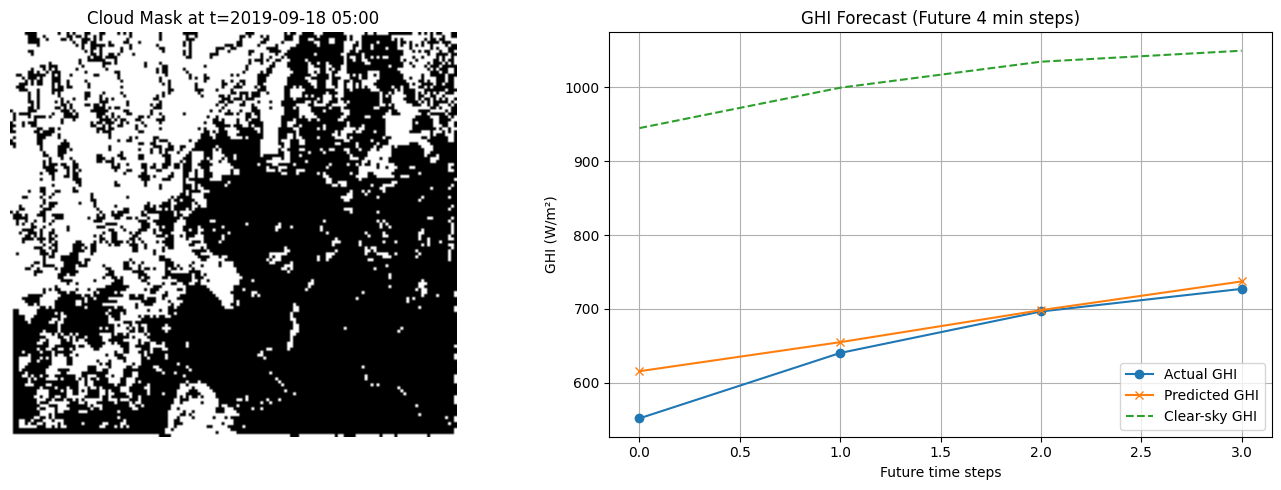

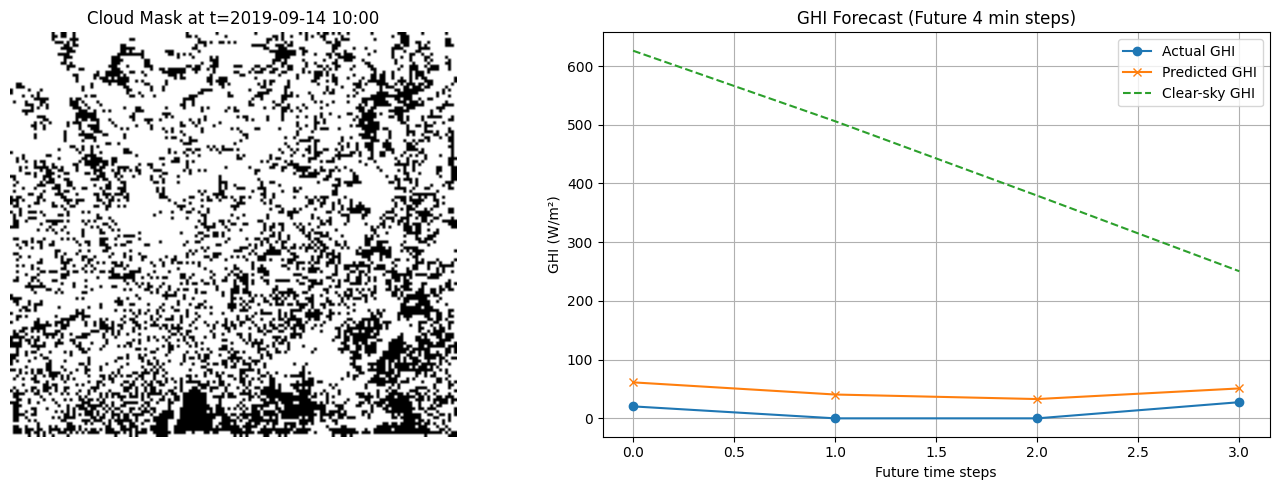

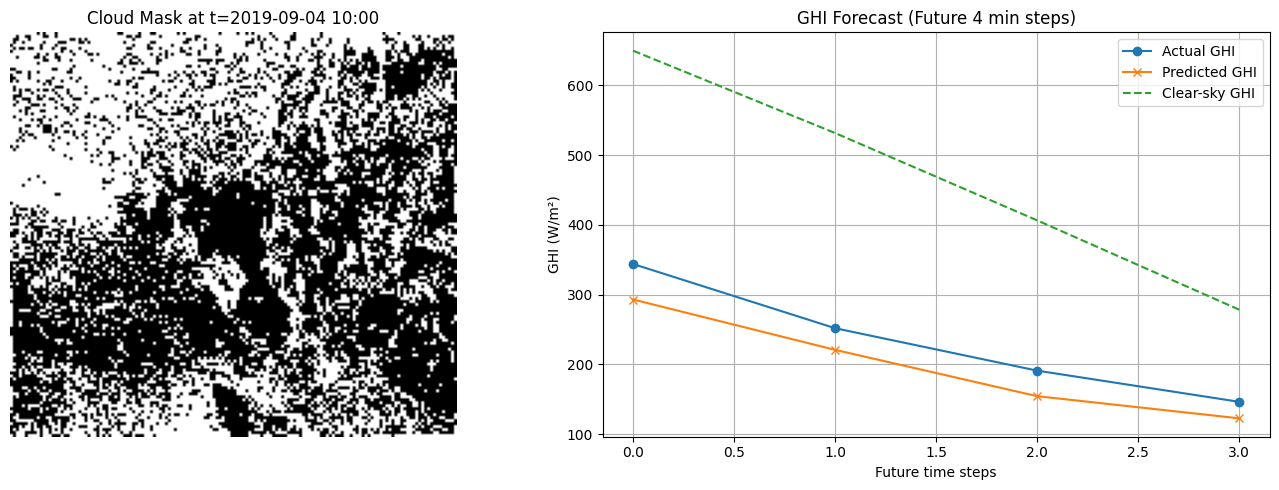


📅 GHI Comparison Sample:
                    timestamp  actual_GHI  predicted_GHI  clear_sky_GHI
80  2019-09-01 11:00:00+05:30  730.206116     761.033081    1002.369465
81  2019-09-01 11:30:00+05:30  820.547852     798.170715    1040.826565
82  2019-09-01 12:00:00+05:30  794.030518     795.839294    1059.432139
83  2019-09-01 12:30:00+05:30  623.874634     785.190369    1057.768821
284 2019-09-01 13:00:00+05:30  576.276672     709.611389    1035.872288
285 2019-09-01 13:30:00+05:30  599.843567     633.344727     994.231038
286 2019-09-01 14:00:00+05:30  627.332153     561.162537     933.783250
287 2019-09-01 14:30:00+05:30  438.134491     473.216675     855.912290
24  2019-09-01 15:00:00+05:30  325.731659     396.716705     762.444071
25  2019-09-01 15:30:00+05:30  283.538574     319.648315     655.653257


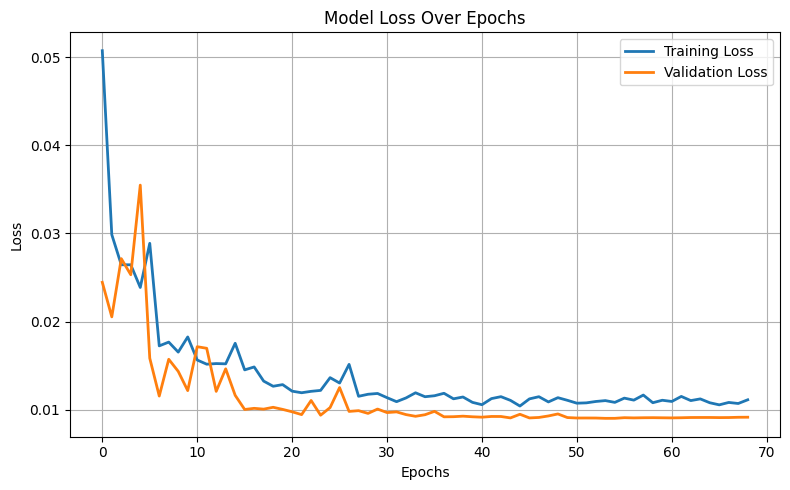

In [ ]:
# ==== STEP 10: PREDICT & INVERSE SCALE ====
y_pred = model.predict(X_val, batch_size=32)
y_pred_denorm = scaler.inverse_transform(y_pred.reshape(-1,1)).reshape(-1, pred_len)
y_val_denorm = scaler.inverse_transform(y_val.reshape(-1,1)).reshape(-1, pred_len)

# Flatten for metrics
flat_y_val = y_val_denorm.flatten()
flat_y_pred = y_pred_denorm.flatten()

# Clear-sky values for the same timestamps
flat_time_val = time_val.flatten()
clear_ghi_val = clearsky.loc[flat_time_val]['ghi'].values

# ==== METRICS ====
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(flat_y_val, flat_y_pred)
rmse = np.sqrt(mean_squared_error(flat_y_val, flat_y_pred))
r2 = r2_score(flat_y_val, flat_y_pred)

print("\n📊 Evaluation Metrics:")
print(f"MAE : {mae:.2f} W/m²")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"R²  : {r2:.2f}")

# ==== PLOTTING: Cloud mask + GHI forecast ====
import matplotlib.pyplot as plt
import numpy as np

# Select top 3 samples with lowest MSE for clear visualization
mse_per_sample = np.mean((y_val_denorm - y_pred_denorm)**2, axis=1)
top_indices = np.argsort(mse_per_sample)[:3]

for idx in top_indices:
    plt.figure(figsize=(14,5))

    # ---- Cloud mask overlay ----
    plt.subplot(1,2,1)
    mask = masks_val[idx]
    plt.imshow(mask, cmap='gray')
    plt.title(f"Cloud Mask at t={time_val[idx][0].strftime('%Y-%m-%d %H:%M')}")
    plt.axis('off')

    # ---- GHI prediction vs actual ----
    plt.subplot(1,2,2)
    plt.plot(range(pred_len), y_val_denorm[idx], label='Actual GHI', marker='o')
    plt.plot(range(pred_len), y_pred_denorm[idx], label='Predicted GHI', marker='x')
    plt.plot(range(pred_len), clear_ghi_val[idx*pred_len:(idx+1)*pred_len], label='Clear-sky GHI', linestyle='--')
    plt.title(f"GHI Forecast (Future {pred_len} min steps)")
    plt.xlabel("Future time steps")
    plt.ylabel("GHI (W/m²)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==== CREATE COMPARISON TABLE ====
import pandas as pd
comparison_df = pd.DataFrame({
    'timestamp': flat_time_val,
    'actual_GHI': flat_y_val,
    'predicted_GHI': flat_y_pred,
    'clear_sky_GHI': clear_ghi_val
})

comparison_df['timestamp'] = comparison_df['timestamp'].dt.tz_convert('Asia/Kolkata')
comparison_df = comparison_df.sort_values('timestamp')

print("\n📅 GHI Comparison Sample:")
print(comparison_df.head(10))

# Optional: Save CSV
comparison_df.to_csv("ghi_comparison_tirupati_september.csv", index=False)

# ==== LOSS PLOT ====
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


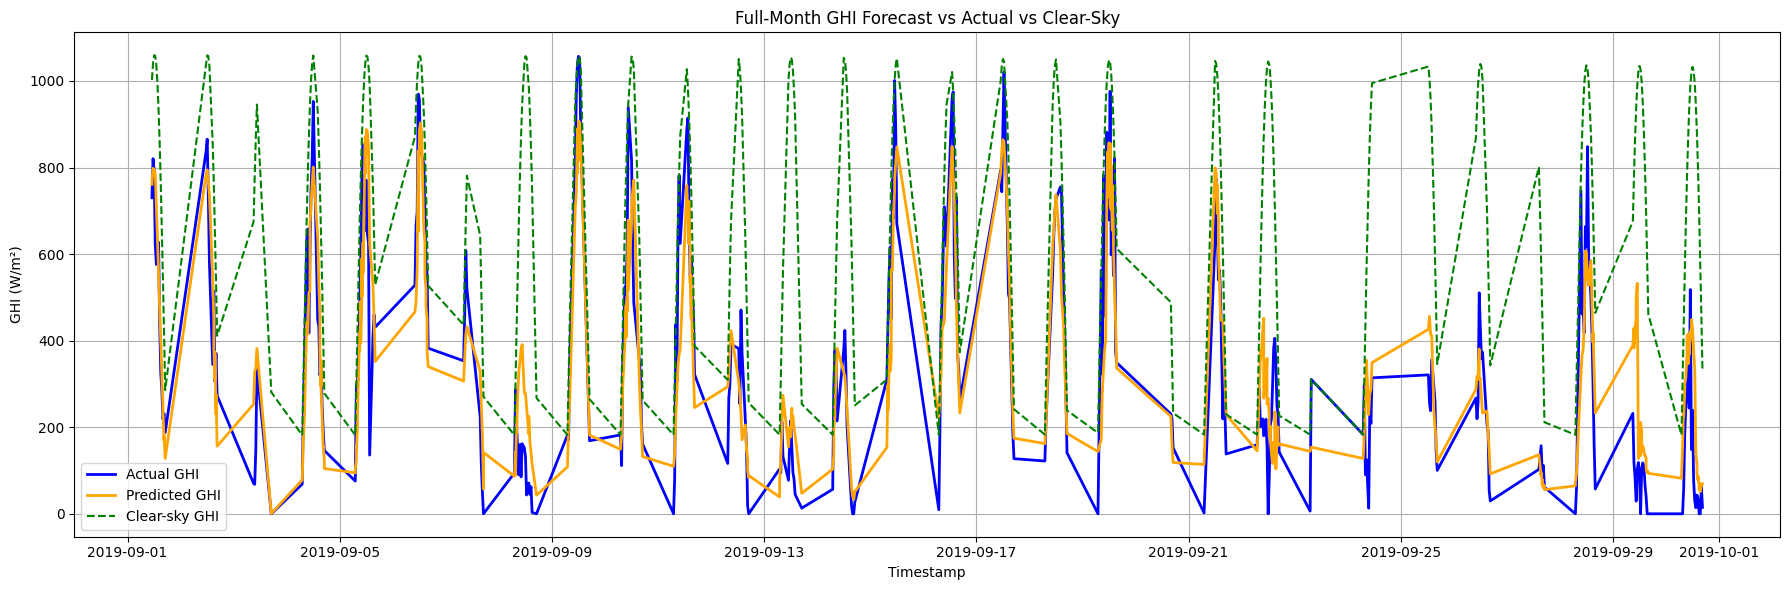

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Flatten predictions and timestamps
y_pred_flat = y_pred_denorm.flatten()
y_val_flat = y_val_denorm.flatten()
time_flat = time_val.flatten()
clear_ghi_flat = clearsky.loc[time_flat]['ghi'].values

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'timestamp': time_flat,
    'actual_GHI': y_val_flat,
    'predicted_GHI': y_pred_flat,
    'clear_sky_GHI': clear_ghi_flat
})

plot_df['timestamp'] = plot_df['timestamp'].dt.tz_convert('Asia/Kolkata')

# Sort by timestamp
plot_df = plot_df.sort_values('timestamp')

# ---- Plot ----
plt.figure(figsize=(18,6))
plt.plot(plot_df['timestamp'], plot_df['actual_GHI'], label='Actual GHI', linewidth=2, color='blue')
plt.plot(plot_df['timestamp'], plot_df['predicted_GHI'], label='Predicted GHI', linewidth=2, color='orange')
plt.plot(plot_df['timestamp'], plot_df['clear_sky_GHI'], label='Clear-sky GHI', linewidth=1.5, color='green', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('GHI (W/m²)')
plt.title('Full-Month GHI Forecast vs Actual vs Clear-Sky')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
